# PMR3409 - Controle II - 2025
# Lab 3 Motor CC: Identificação de sistemas em tempo discreto

# Identificação

**Aluno 1 : Edilson Elias Barbosa Guedes Dias**           **NUSP:13726042**

**Aluno 2 : Giovanni Cangiano**           **NUSP:10705892** 

**Turma de Laboratório: 3A**

**Professor: Oswaldo Horikawa**

**OBS: Você deve submeter o seu relatório em um arquivo compactado contendo os seguintes arquivos:**

- Arquivo *.ipynb.
- Diretório contendo todas as figuras do seu relatório.
- **Arquivo *.html equivalente ao seu arquivo *.ipynb. Menu: File -> Download as -> HTML**

## 1. Introdução:

O primeiro passo para o projeto de um sistema de controle é a obtenção de um modelo matemático do sistema a ser controlado.

Usualmente princípios físicos fundamentais são utilizados para a obtenção de equações diferenciais.
Eventualmente todos os parâmetros físicos são conhecidos o que permite calcular os coeficientes das equações diferenciais.

Entretanto para muitos sistemas a modelagem totalmente física não é trivial e a estimação de parâmetros através de procedimentos experimentais pode ser uma alternativa viável.

Por exemplo, na figura abaixo é ilustrado um kit didático de motor CC da LJCreate. O kit possui um driver de motor CC analógico. A velocidade angular do motor é monitorada por um outro motor CC que funciona como tacômetro e a posição  angular é monitorada por um potenciômetro rotativo sem fim (-180,+180 graus correspondendo a uma saída de -5, +5 Volts).
Um sistema de freio magnético (Eddy current brake) com 3 posições (sem acoplamento magnético, acoplamento
parcial e acoplamento total) gera um distúrbio de torque no sistema.

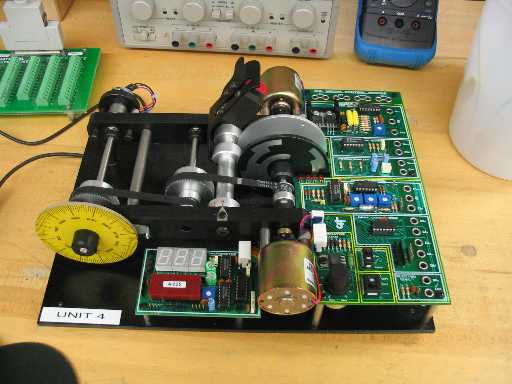

Utilizando um gerador de funções é possível injetar um sinal elétrico de referência $u$ para o motor CC e observar a velocidade angular $\omega$ e a posição angular $\theta$ através dos sensores.

Através de uma placa de aquisição de dados uma sequência de $N$ valores dessas variáveis pode ser armazenada:

$$
\begin{array}{ccc}
u(\,0h\,)  & \omega(\,0h\,) & \theta(\,0h\,) \\
u(\,1h\,)  & \omega(\,1h\,) & \theta(\,1h\,) \\
\ldots & \ldots \\
u(\,(N-1)h\,)  & \omega( (N-1)\,0h\,) &  \theta( (N-1)\,0h\,) \\
\end{array}
$$
onde $h$ é o intervalo de amostragem.

Utilizando algumas hipóteses é possível estimar a função de transferência no domínio discreto e posteriormente calcular a função de transferência no domínio contínuo. 

## 2. Aquisição de dados

Para a realização da aquisição de dados serão utilizados utilizados dois Scripts Matlab:
- **IdentificacaoOpenLoopV1.m**: para identificação em malha aberta da função de transferência de velocidade.
- **IdentificacaoClosedLoopV1.m**: para identificação em malha fechada da função de transferência de posição.

Nos scripts os seguintes parâmetros podem ser escolhidos:
- **A**: amplitude da onda quadrada de excitação do sistema, para a função de transferência de velocidade
  é utilizado uma excitação com onda quadrada simétrica (+A,-A) e para a função de transferência de posição
  é utilizado uma excitação com onda quadrada não simétrica(0,+A).
- **Per**: período da onda quadrada.
- **Fa**: taxa de amostragem (Amostras/seg).
- **Duration**: duração do experimento em segundos.
- Nome do arquivo de dados aonde serão gravados os dados do experimento **(modificar no final do arquivo)**.

No kit de motor CC podemos selecionar três posições distintas para o freio magnético:
- Sem acoplamento magnético,
- Acoplamento magnético parcial,
- Acoplamento magnético completo.

## 3.1 Função de transferência da velocidade angular: sistema de 1a. ordem

A função de transferência da velocidade angular de um motor elétrico CC pode ser reduzido à seguinte expressão:

$$
\frac{\Omega(s)}{U(s)} = G_\omega(s) = \frac{K_\omega}{\tau s+1}
$$

A malha de controle digital possui sinais de tempo discreto e de tempo contínuo.
Para efeito de projeto e análise é necessário converter a parte de tempo contínuo para
tempo discreto. Deve ser incorporada à função de transferência da planta a função de
transferência do segurador de ordem zero (ZOH) como observado na figura abaixo.

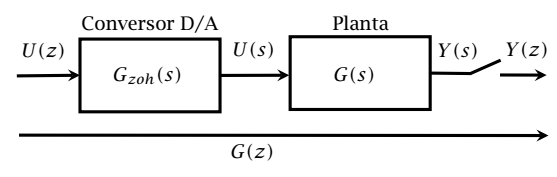

A função de transferência discreta do sistema considerando o segurador de Ordem zero na entrada do sistema pode ser calculada da seguinte forma:
$$
G_\omega (z) = (1-z^{-1}) {\cal{L}} \left\{ \frac{G_\omega(s)}{s} \right\},
$$
que resulta em:

$$
G_\omega(z) = \frac{b_1}{z+a_1} = \frac{b_1z^{-1}}{1+a_1z^{-1}}
$$

onde:
$$
b_1 = K_\omega (1-\exp\{-h/\tau\}),
$$
e
$$
a_1 = - \exp\{-h/\tau\}.
$$

A equação de diferenças correspondente pode ser escrita como:
$$
\omega (\,kh\,) = -a_1\omega(\, (k-1)h\,) + b_1 u(\,(k-1)h\,)
$$
Para evitar o uso do sinal negativo podemos fazer $A_1=-a_1$,
$$
\omega (\,kh\,) = A_1\omega(\, (k-1)h\,) + b_1 u(\,(k-1)h\,)
$$

Para $N$ observações obtemos:
$$
\begin{align}
\omega (\,1h\,) & = A_1\omega(\,0h\,) + b_1 u(\,0h\,) \\
\omega (\,2h\,) & = A_1\omega(\,1h\,) + b_1 u(\,1h\,) \\
\ldots \\
\omega (\,(N-1)h\,) & = A_1\omega(\,(N-2)h\,) + b_1 u(\,(N-2)h\,)
\end{align}
$$

Que pode ser escrita como:

$$
W = A p,
$$
onde:
$$
A= \left[
\begin{array}{cc}
\omega(\,0h\,)  & u(\,0h\,) \\
\omega(\,1h\,)  & u(\,1h\,) \\
\ldots & \ldots \\
\omega(\,(N-2)h\,)  & u( (N-2)\,0h\,) \\
\end{array}
\right],
$$

$$
W = \left[
\begin{array}{c}
\omega(\,1h\,) \\
\omega(\,2h\,) \\
\ldots  \\
\omega(\,(N-1)h\,)  \\
\end{array}
\right],
$$
e
$$
p = \left[
\begin{array}{c}
A_1 \\
b1
\end{array}
\right],
$$

O vetor de parâmetros $p$ pode ser estimado através do método de mínimos quadrados cuja solução pode ser escrita como:
$$
p = A^{+}W,
$$
onde $A^{+}$ é a matrix pseudo-inversa definida como:
$$
(A^TA)^{-1}A^T.
$$

Obviamente utilizando as estimavas de $A_1$ e $b_1$ é possível estimar os parâmetros $K_\omega$ e $T$.

## 3.2 Atividades

a-) Aquisição de dados: 
    
Quatro diferentes configurações devem ser consideradas:
- OLM1: sem acoplamento magnético, amplitude A=1.5 Volts, taxa de amostragem: 20Hz, duração do experimento 20 segundos.
- OLM2: acoplamento magnético parcial, amplitude A=1.5 Volts, taxa de amostragem: 20Hz, duração do experimento 20 segundos.
- OLM3: sem acoplamento magnético, amplitude A=3.5 Volts, taxa de amostragem: 20Hz, duração do experimento 20 segundos.
- OLM4: acoplamento magnético parcial, amplitude A=3.5 Volts, taxa de amostragem: 20Hz, duração do experimento 20 segundos.

**Para cada experimento selecionar um nome de arquivo de dados *.txt (no final do script) diferente.**

**Nos ítens a seguir utilizar a célula de código abaixo**

**Cada ítem requer cálculos de estimavas de grandezas para cada experimento**

b-) Gerar os gráficos do conjunto de dados de cada experimento.

1- OLM1
    
![Gráfico de resultados](OLM1.jpg)

2- OLM2
    
![Gráfico de resultados](OLM2.jpg)

3- OLM3
    
![Gráfico de resultados](OLM3.jpg)

4- OLM4
    
![Gráfico de resultados](OLM4.jpg)

c-) Estimar os valores dos parâmetros da função de transferência do domínio $z$ para cada experimento:

$$
G_{\omega}(z) = \frac{b_1}{z+a_1}
$$

|     |  OLM1  |  OLM2 | OLM3 | OLM4 |
| :-  | :- | :- | :- | :- |
| $a_1$ | 0.808 | 0.761 | 0.9029 | 0.8658 |
| $b_1$ | 0.1685 | 0.164 | 0.0967 | 0.1043 |

d-) Calcule o valor do ganho estático de $G_\omega(z)$ para cada função de transferência:

|     |  OLM1  |  OLM2 | OLM3 | OLM4 |
| :-  | :- | :- | :- | :- |
| Ganho Estático | 0.8776 | 0.6862 | 0.9959 | 0.7772 |

e-) Indique o valor do pólo de $G_\omega(z)$:

|     |  OLM1  |  OLM2 | OLM3 | OLM4 |
| :-  | :- | :- | :- | :- |
| pólo | 0.808 | 0.761 | 0.9029 | 0.8658 |

f-) Partindo dos valores de $a_1$ e $b_1$ calcule os valores
    estimados de $K_\omega$ e $\tau$ para cada experimento (Utilize célula abaixo):

|     |  OLM1  |  OLM2 | OLM3 | OLM4 |
| :-  | :- | :- | :- | :- |
| $K_\omega$ | 0.8776 | 0.6862 | 0.9959 | 0.7772 |
| $\tau$ | 0.2345 | 0.1831 | 0.4895 | 0.347 |

**Analise os resultados.**

**Resposta:**

g-) Realize uma simulação utilizando a função de transferência de tempo discreto estimada $G_\omega(z)$
    com o mesmo sinal de entrada $u(t)$ experimental.

- Coloque no mesmo gráfico os pontos amostrados de $\omega$ e $u$ do arquivo de dados e os valores de $\omega$ estimados através da função de transferência de tempo discreto.
- Repetir para cada experimento.

1- OLM1
    
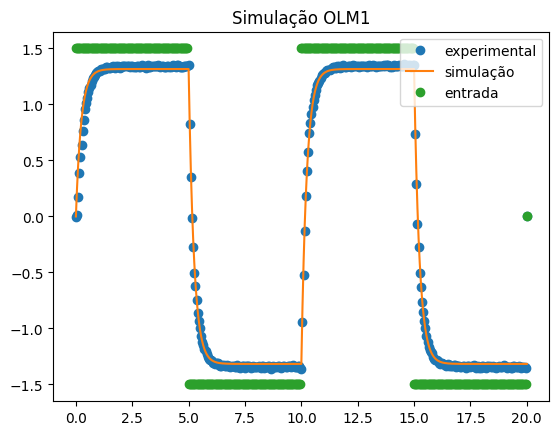

2- OLM2
    
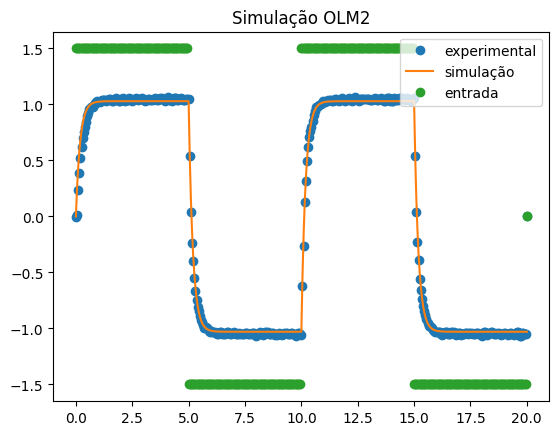

3- OLM3
    
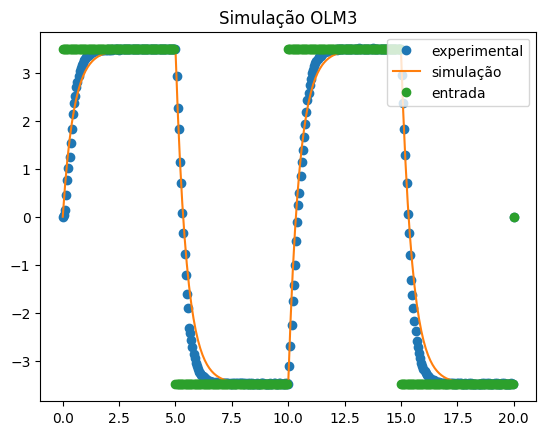

4- OLM4
    
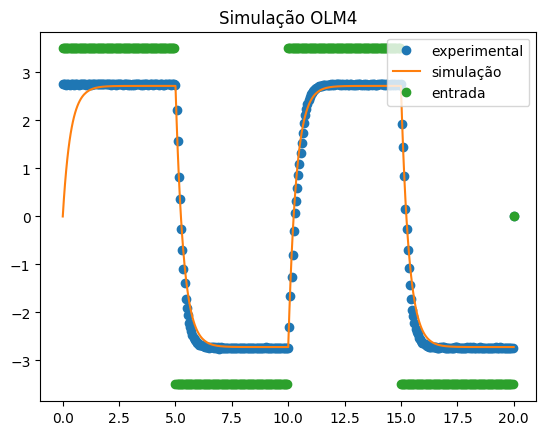

**Analise os resultados.**

**Resposta:**

### Código para estimação de parâmetros função de transferência de velocidade angular

Numero de pontos Np =  401
[a1 b1] = [  0.808   0.1685  ]


---------------------------------
Funcao de transferencia dominio z
Gw(s) =  <TransferFunction>: sys[84]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


 0.1685
---------
z - 0.808

dt = 0.05

---------------------------------
Polos, Zeros, Ganho Estatico
Polos =  [0.808+0.j]
Zeros =  []
Ganho estatico =  0.8776
---------------------------------


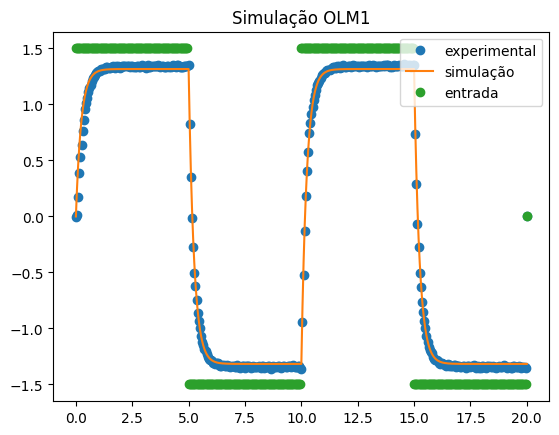

Numero de pontos Np =  401
[a1 b1] = [  0.761   0.164  ]


---------------------------------
Funcao de transferencia dominio z
Gw(s) =  <TransferFunction>: sys[86]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  0.164
---------
z - 0.761

dt = 0.05

---------------------------------
Polos, Zeros, Ganho Estatico
Polos =  [0.761+0.j]
Zeros =  []
Ganho estatico =  0.6862
---------------------------------


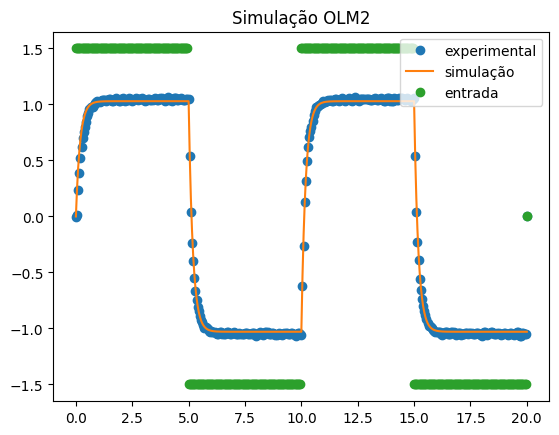

Numero de pontos Np =  401
[a1 b1] = [  0.9029   0.0967  ]


---------------------------------
Funcao de transferencia dominio z
Gw(s) =  <TransferFunction>: sys[88]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  0.0967
----------
z - 0.9029

dt = 0.05

---------------------------------
Polos, Zeros, Ganho Estatico
Polos =  [0.9029+0.j]
Zeros =  []
Ganho estatico =  0.9959
---------------------------------


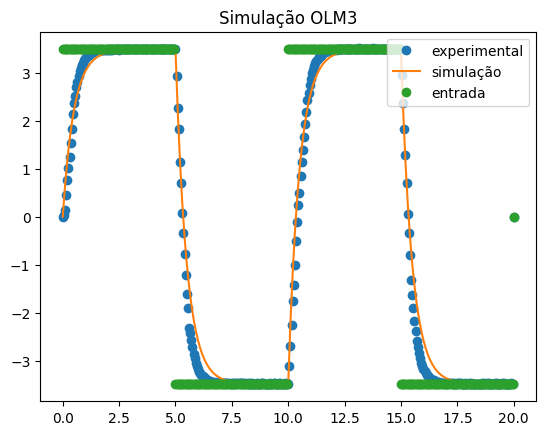

Numero de pontos Np =  401
[a1 b1] = [  0.8658   0.1043  ]


---------------------------------
Funcao de transferencia dominio z
Gw(s) =  <TransferFunction>: sys[90]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  0.1043
----------
z - 0.8658

dt = 0.05

---------------------------------
Polos, Zeros, Ganho Estatico
Polos =  [0.8658+0.j]
Zeros =  []
Ganho estatico =  0.7772
---------------------------------


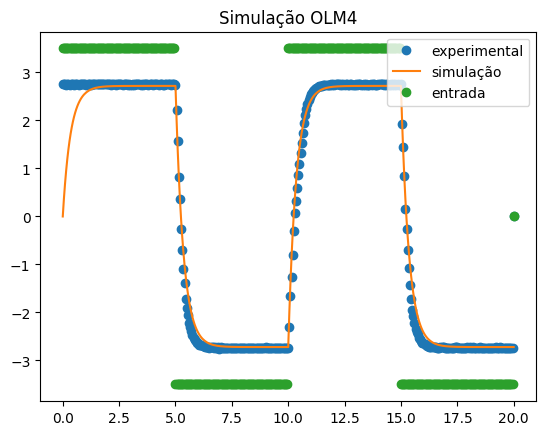

In [24]:
#%matplotlib qt
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt
import control.matlab as co
from scipy import signal
#
# Leitura do arquivo de dados gerado pelo Script Matlab
#
# coluna 1 = t (tempo em segundos)
# coluna 2 - vetoruk (sinal de entrada de referencia em volts)
# coluna 3 - vetoryk (sinal de saida, velocidade angular, em volts)
#
for i in range(1,5):
    a = np.loadtxt("OLM"+str(i)+".txt", dtype=float)     # <--------- modifique aqui o nome do arquivo
    t = a[:,0]
    u = a[:,1]
    w = a[:,2]
    h = t[1]-t[0] # <--------------------------------intervalo de amostragem
    #
    # Esses objetos provenientes da library numpy
    # possuem posicao de indice 0
    # u[0], w[0] existem
    #
    plt.plot(t,w,'o', label="experimental")
    plt.grid()
    # Dimensao do vetor u e w
    Np = len(u)
    # Ao inves de utilizar todos os pontos
    # Podemos reduzir atribuindo um valor de Np
    # menor do que a dimensao total
    #Np = 20
    print('Numero de pontos Np = ',Np)
    # Wk, Wkminus1 e Ukminus1 sao objetos do tipo
    # matrix da library numpy
    #
    # Estimacao dos parametros
    #
    Wk = w[1:Np];
    Wkminus1 = w[0:Np-1];
    Ukminus1 = u[0:Np-1];
    A = np.column_stack((Wkminus1, Ukminus1))
    # vetor p contem os parametros
    p = np.matmul(np.linalg.pinv(A), Wk)            # <---------- Utilizacao da pseudo inversa
    A1 = round(p[0],4)
    b1 = round(p[1],4)
    print('[a1 b1] = [ ',A1,' ',b1,' ]')
    a1 = -A1
    Gwd = co.tf([b1],[1,a1],h)
    print('\n\n---------------------------------')
    print('Funcao de transferencia dominio z')
    print('Gw(s) = ',Gwd)
    print('---------------------------------')
    print('Polos, Zeros, Ganho Estatico')
    print('Polos = ',co.pole(Gwd))
    print('Zeros = ',co.zero(Gwd))
    print('Ganho estatico = ',np.round(co.dcgain(Gwd),4))
    print('---------------------------------')
    #
    # Simulacao do sistema de tempo discreto com os parâmetros estimados
    #
    wd, t,xout = co.lsim(Gwd,u,t)
    plt.plot(t,wd, label="simulação")
    plt.plot(t,u,'o',label="entrada")
    plt.legend(loc="upper right")
    plt.title("Simulação OLM" + str(i))
    plt.grid()
    plt.show()

### Código para estimação da função de transferência no domínio do tempo contínuo

$$
G_{\omega} = \frac{K_{\omega}}{\tau s + 1}
$$

In [12]:
Tau = -h/math.log(-a1)
Kw = b1/(1-math.exp(-h/Tau))
print('Tau = ',round(Tau,4)) # arredonda para 4 casas decimais
print('Kw = ',round(Kw,4))

Tau =  0.2345
Kw =  0.8776


## 4.1 Função de transferência de posição: sistema de 2a. ordem

A função de transferência da posição angular pode ser escrita como:
$$
\frac{\Theta(s)}{U(s)} = G_\theta(s) = \frac{K_\theta}{s(Ts+1)}
$$

A função de transferência discreta do sistema considerando o segurador de Ordem zero na entrada do sistema pode ser calculada da seguinte forma:
$$
G_\theta (z) = (1-z^{-1}) {\cal{L}} \left\{ \frac{G_\theta(s)}{s} \right\},
$$
que resulta em:

$$
G_\theta(z) = K_\theta \frac{b_1z+b_2}{z^2 +a_1z+a_2} = K_\theta \frac{b_1z^{-1}+b_2z^{-2}}{1 +a_1z^{-1}+a_2^{-2}}
$$
onde:

$b_1=\tau(h/\tau-1+\exp(-h/\tau))$,

$b_2=\tau(1-\exp(-h/\tau)-(1/\tau)\exp(-h/\tau))$,

$a_1 = -(1+\exp(-h/\tau))$,

$a_2=\exp(-h/\tau)$.

A equação de diferenças pode ser escrita como:
$$
\theta(\, kh \,) = -a_1 \theta(\, (k-1)h \,) -a_2 \theta(\, (k-2)h \,) + K_\theta b_1 u(\, (k-1)h \,) + K_\theta b_2 u(\, (k-2)h \,)
$$
Para o nosso propósito vamos reescrever a equação da seguinte forma:
$$
\theta(\, kh \,) = A_1 \theta(\, (k-1)h \,) A_2 \theta(\, (k-2)h \,) + B_1 u(\, (k-1)h \,) + B_2 u(\, (k-2)h \,),
$$
onde $A_1=-a_1$, $A_2=-a_2$, $B_1=K_\theta b_1$ e $B_2=K_\theta b_2$.

Para $N$ observações podemos  definir:
$$
A= \left[
\begin{array}{cc}
\theta(\, 1h \,) & \theta(\, 0h \,) & u(\, 1h \,) & u(\, 0h \,) \\
\theta(\, 2h \,) & \theta(\, 1h \,) & u(\, 2h \,) & u(\, 1h \,) \\
\ldots & \ldots \\
 \theta(\, (N-2)h \,) & \theta(\, (N-3)h \,) & u(\, (N-2)h \,) & u(\, (N-3)h \,) 
\end{array}
\right],
$$
$$
W = \left[
\begin{array}{c}
\theta(\,2h\,) \\
\theta(\,3h\,) \\
\ldots  \\
\theta(\,(N-1)h\,)  \\
\end{array}
\right],
$$
e
$$
p = \left[
\begin{array}{c}
A_1 \\
A_2 \\
B_1 \\
B_2
\end{array}
\right].
$$
A equação pode então ser escrita como:
$$
W = A p,
$$
e o vetor de parâmetros $p$ pode ser calculado pelo mesmo método do ítem anterior.

## 4.2 Atividades

a-) Aquisição de dados: 
    
Duas diferentes configurações devem ser consideradas:
- CLM1: sem acoplamento magnético, amplitude A=1.5 Volts, taxa de amostragem: 10Hz, duração do experimento 40 segundos.
- CLM2: sem acoplamento magnético, amplitude A=3.5 Volts, taxa de amostragem: 10Hz, duração do experimento 40 segundos.

**Para cada experimento selecionar um nome de arquivo de dados *.txt (no final do script) diferente.**

**Posicionar manualmente o potenciômetro de tal forma a fornecer 0 Volts (Verificar no osciloscópio)**

**Nos ítens a seguir utilizar a célula de código abaixo**

**Cada ítem requer cálculos de estimavas de grandezas para cada experimento**

b-) Gerar os gráficos do conjunto de dados para cada experimento.

1- CLM1
    
![Gráfico de resultados](CLM1.jpg)

2- CLM2
    
![Gráfico de resultados](CLM2.jpg)

c-) Estimar os valores dos parâmetros da função de transferência do domínio $z$ para cada experimento:

**Nesse item é aconselhado a utilização de apenas parte dos dados para a estimação dos parâmetros.
Um ciclo de subida e um ciclo de descida (Veja célula abaixo).**

$$
G_\theta(z) = K_\theta \frac{b_1z+b_2}{z^2+a_1z+a_2}
$$

| c |a1|a2|b1|b2|
|:-| :- | :- | :- | :- |
CLM1|-1.3338|0.3641|0.03705|0.0524|
CLM2|-1.554|0.546|0.02498|0.03469|

d-) Indique o valor dos pólos e o zero de $G_\theta(z)$ para cada experimento:

|  c  |pólo 1|pólo 2| zero |
| :- | :- | :- | :- |
| CLM1 | 0.9509| 0.3829 | -1.4144 |
| CLM2  | 1.0173 | 0.5367 | -1.3891 |


e-) Partindo dos valores de $a_1$, $a_2$, $b_1$ e $b_2$ calcule os valores
    estimados de $K_\theta$ e $\tau$ para cada experimento (Utilize célula abaixo):

| c |$K_\theta$|$\tau$|
| :- | :- | :- |
| CLM1 | 3.6266 | 0.099 |
| CLM2 | 6.2261 | 0.1653 |

**Analise os resultados.**

**Resposta:**

f-)  Realize uma simulação em malha fechada utilizando a função de transferência de tempo discreto estimada $G_\theta(z)$ com o mesmo sinal de entrada $r(t)$ experimental. Lembre-se que durante os experimentos foi utilizado um controlador proporcional ($K_p=0.5$).

- Coloque no mesmo gráfico os pontos amostrados de $\theta(t)$ e $r(t)$ do arquivo de dados e os valores de $\theta$ estimados através da função de transferência de tempo discreto.
- Repetir para cada experimento.
    
1- CLM1
    
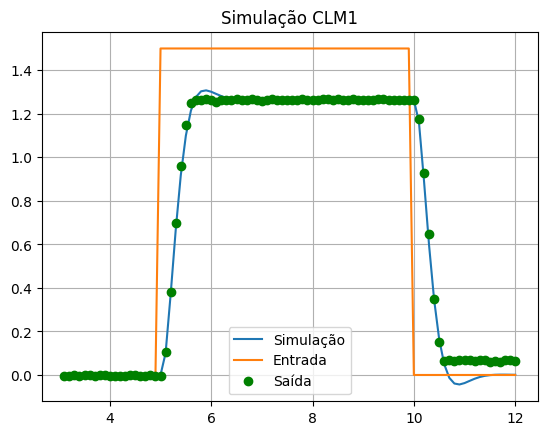

2- CLM2
    
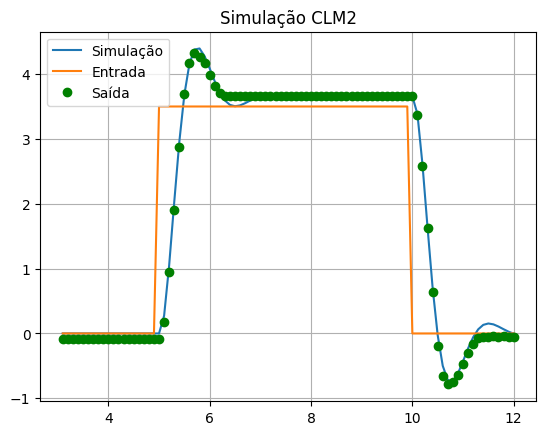

**Analise os resultados.**

**Resposta:**

### Código para estimação de parâmetros função de transferência de posição angular

Intervalo de amostragem h =  0.1
Ktheta =  6.2261  Tau =  0.1653
[a1 a2 b1 b2] = [  -1.554   0.546   0.024975580283105574   0.034692767467207744  ]


---------------------------------
Funcao de transferencia dominio z
Gtheta(s) =  <TransferFunction>: sys[146]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']


  0.1555 z + 0.216
---------------------
z^2 - 1.554 z + 0.546

dt = 0.10000000000000009

---------------------------------
Polos, Zeros, Ganho Estatico
Polos =  [1.0172686+0.j 0.5367314+0.j]
Zeros =  [-1.38906752+0.j]
Ganho estatico =  -46.4375
---------------------------------


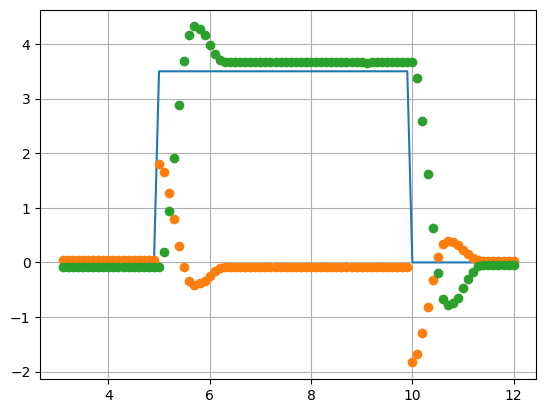

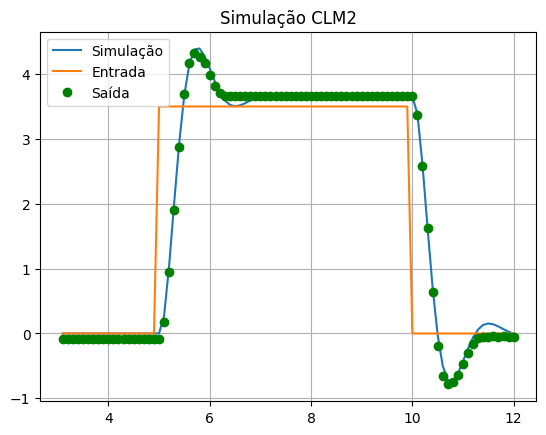

In [34]:
#%matplotlib qt
%matplotlib inline
import math
import numpy as np
import matplotlib.pyplot as plt
import control.matlab as co
import control as ct
from scipy import signal
#
# Leitura do arquivo de dados gerado pelo Script Matlab
#
# coluna 1 = t (tempo em segundos)
# coluna 2 - vetorrk (sinal de referencia em volts)
# coluna 3 - vetoruk (sinal de atuacao, entrada da planta, em volts)
# coluna 4 - vetoryk (sinal de saida, potenciometro, em volts)
a = np.loadtxt("CLM2.txt", dtype=float)   # <------------------ arquivo de dados
# 
# Aqui voce pode escolher uma janela de tempo especificado
# pelos indices do vetor de tempo (inicio, fim)
# para Fa = 10Hz
# inicio = 31 (t = 3segundos)
# fim = 121   (t = 12segundos)
#
a = a[31:121,:]
t = np.round(a[:,0],2);
r = a[:,1];
u = a[:,2];
theta = a[:,3];
h = t[1]-t[0];     # <--------------------------------intervalo de amostragem
print('Intervalo de amostragem h = ',round(h,3))
#
# Esses objetos provenientes da library numpy
# possuem posicao de indice 0
# u[0], w[0] existem
#
plt.figure(1)
plt.plot(t,r,t,u,'o',t,theta,'o')
plt.grid()
# Dimensao do vetor u mesma de t, r e theta
Np = len(u)
# Ao inves de utilizar todos os pontos
# Podemos reduzir atribuindo um valor de Np
# menor do que a dimensao total
#Np = 20
#
# Estimacao dos parametros
#
Thetak = theta[2:Np-1];
Thetakminus2 = theta[0:Np-3];
Thetakminus1 = theta[1:Np-2]
Ukminus2 = u[0:Np-3];
Ukminus1 = u[1:Np-2]
A = np.column_stack((Thetakminus1,Thetakminus2, Ukminus1,Ukminus2))
#
# vetor p contem os parametros
#
#  p = A*Thetak
p = np.matmul(np.linalg.pinv(A), Thetak)   # <---------- Utilizacao da pseudo inversa
A1 = round(p[0],4)
A2 = round(p[1],4)
B1 = round(p[2],4)
B2 = round(p[3],4)
a1=-A1
a2=-A2
#
# Estimativa dos parametros da funcao de transferencia
# do tempo continuo Gtheta: Ktheta e Tau
# e de tempo discreto Gthetad: a1, a2, b1, b2
#
Tauhat = -h/math.log(a2)
b1=Tauhat*(h/Tauhat-1+math.exp(-h/Tauhat))
Kthetahat=B1/b1
b1=B1/Kthetahat
b2=B2/Kthetahat
print('Ktheta = ',round(Kthetahat,4),' Tau = ',round(Tauhat,4))
print('[a1 a2 b1 b2] = [ ',a1,' ',a2,' ',b1,' ',b2,' ]')
Gthetad = co.tf([Kthetahat*b1,Kthetahat*b2],[1,a1,a2],h)
print('\n\n---------------------------------')
print('Funcao de transferencia dominio z')
print('Gtheta(s) = ',Gthetad)
print('---------------------------------')
print('Polos, Zeros, Ganho Estatico')
print('Polos = ',co.pole(Gthetad))
print('Zeros = ',co.zero(Gthetad))
print('Ganho estatico = ',np.round(co.dcgain(Gthetad),4))
print('---------------------------------') 
#
#
Kp = 0.5 # lembre-se que no matlab escolhemos Kp=0.5
#
# Simulacao do sistema discreto em malha fechada
#
cloop = co.feedback(Kp*Gthetad,1)
# note que nao foi usado o vetor t aqui como argumento de entrada
# isso e' necessario se t nao comecar do t=0.0
thetad, t1, xout = co.lsim(cloop,r)
plt.figure(2)
# no grafico utilizamos t novamente
plt.title("Simulação CLM2")
plt.plot(t,thetad, label="Simulação")
plt.plot(t,r, label="Entrada")
plt.plot(t,theta,'og', label="Saída")
plt.legend()
plt.grid()

## 5. Discussões


## 6. Conclusões
